In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [ ]:
base = pd.read_csv('AirPassengers.csv')
base.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
base.shape

(144, 1)

In [ ]:
print(base.dtypes)

Month          object
#Passengers     int64
dtype: object


In [ ]:
dataparse = lambda dates: datetime.strptime(dates, '%Y-%m')
base = pd.read_csv(
    'AirPassengers.csv',
    parse_dates=['Month'],
    index_col='Month',
    date_parser= dataparse
)
base

/tmp/ipykernel_1437/3022953912.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  base = pd.read_csv(


,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
base.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [ ]:
ts = base['#Passengers']
ts

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
ts[1]

/tmp/ipykernel_1437/4108791374.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ts[1]


np.int64(118)

In [ ]:
ts['1949-02']

,#Passengers
Month,
1949-02-01,118


In [ ]:
ts[datetime(1949, 2, 1)]

np.int64(118)

In [ ]:
ts['1950-01-01': '1950-07-31']

,#Passengers
Month,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170


In [ ]:
ts[: '1950-07-31']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [ ]:
ts['1950']

,#Passengers
Month,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170
1950-08-01,170
1950-09-01,158


In [ ]:
ts.index.max()

Timestamp('1960-12-01 00:00:00')

In [ ]:
ts.index.min()

Timestamp('1949-01-01 00:00:00')

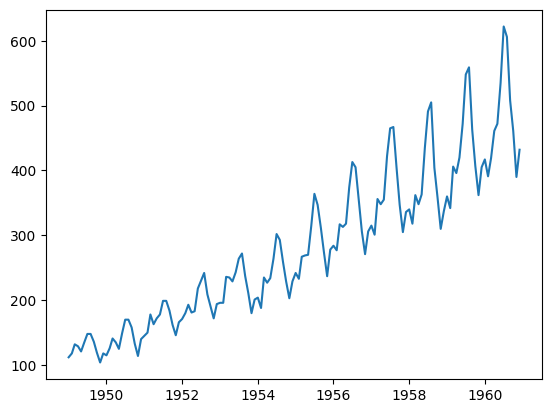

In [ ]:
plt.plot(ts)

/tmp/ipykernel_1437/81706552.py:1: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  ts_ano = ts.resample('A').sum()


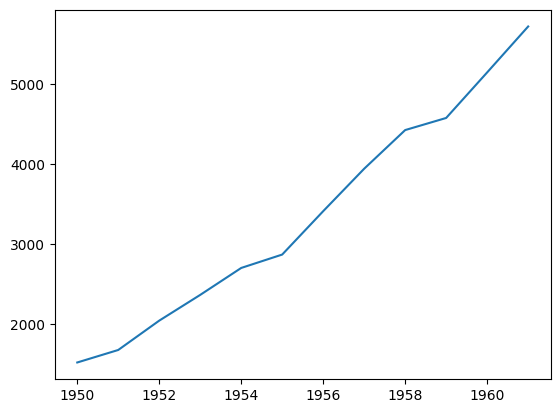

In [ ]:
ts_ano = ts.resample('A').sum()
plt.plot(ts_ano)

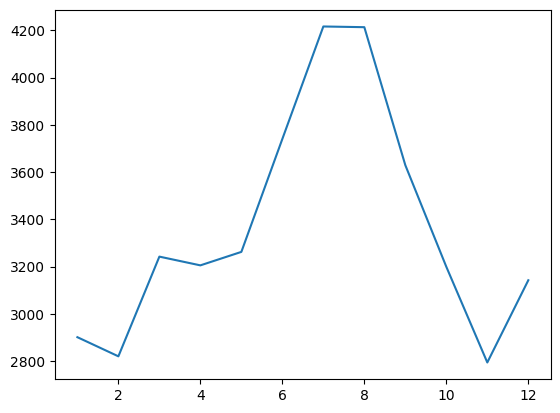

In [ ]:
ts_mes = ts.groupby([lambda x: x.month]).sum()
plt.plot(ts_mes)

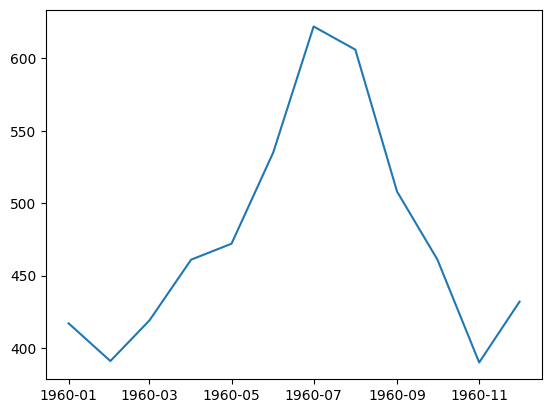

In [ ]:
ts_datas = ts['1960-01-01': '1960-12-01']
plt.plot(ts_datas)